In [89]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded ✅")


Libraries loaded ✅


In [88]:
df = pd.read_csv("test.csv")

df.head(10)

,Credit_Score,Changed_Credit_Limit_woe,Num_Bank_Accounts_woe,Payment_of_Min_Amount_woe,Num_Credit_Card_woe,Monthly_Balance_woe,Monthly_Inhand_Salary_woe,Credit_History_Age_woe,Age_woe,Num_of_Loan_woe,Num_Credit_Inquiries_woe,Amount_invested_monthly_woe,Payment_Behaviour_woe,Outstanding_Debt_woe,Total_EMI_per_month_woe,Credit_Mix_woe,Annual_Income_woe,Interest_Rate_woe,Credit_Utilization_Ratio_woe,Occupation_woe,Delay_from_due_date_woe,Num_of_Delayed_Payment_woe
0,0,-0.053037,-0.768975,-0.972161,-1.082462,0.099263,-0.027824,-1.133933,0.579770,0.104120,-1.071835,0.179470,0.079801,-1.236778,0.125712,-0.542231,0.378775,-1.054083,0.008324,0.063263,-1.574914,-0.609872
1,0,-0.053037,-0.768975,-0.972161,-1.082462,-0.274705,-0.027824,-1.133933,0.088683,0.104120,-1.071835,0.179470,-0.054389,-1.236778,0.125712,-0.542231,0.378775,-1.054083,0.008324,0.063263,-0.890656,-0.609872
2,0,-0.053037,-0.768975,-0.972161,0.949413,-0.274705,-0.027824,-1.133933,0.088683,-0.903060,-1.071835,0.179470,-0.392684,-1.236778,0.125712,0.000993,-0.288995,-1.054083,0.008324,0.063263,-1.574914,-0.609872
3,0,-0.053037,-0.768975,-0.972161,-1.082462,-0.274705,-0.027824,-1.133933,0.088683,-0.903060,-1.071835,0.025707,0.320741,-1.236778,0.125712,-0.542231,-0.288995,-1.054083,0.008324,0.063263,-1.574914,-0.609872
4,0,-0.053037,-0.768975,-0.972161,-1.082462,-0.274705,-0.027824,-1.133933,0.088683,-0.903060,-1.071835,-0.156278,0.320741,-1.236778,0.125712,-0.542231,-0.288995,-1.054083,0.008324,0.063263,-1.574914,-0.609872
5,0,-0.053037,-0.768975,-0.972161,0.044620,-0.842592,-1.001701,-0.014789,0.088683,-0.324882,-1.071835,0.025707,-0.054389,-0.210979,0.125712,-0.542231,-0.979313,-1.054083,0.008324,-0.069864,-0.890656,-0.609872
6,0,-0.053037,-0.768975,-0.972161,0.044620,-0.274705,-1.001701,-0.014789,0.088683,-0.324882,-1.071835,-0.415281,0.079801,-0.210979,0.125712,0.000993,-0.979313,-1.054083,-0.085890,0.063263,-0.890656,-0.609872
7,0,-0.053037,-0.768975,-0.972161,0.044620,-0.842592,-1.001701,-0.014789,0.088683,-0.324882,-1.071835,-0.415281,-0.054389,-0.210979,0.125712,-0.542231,-0.979313,-1.054083,0.008324,-0.069864,-0.890656,-0.609872
8,0,-0.053037,-0.768975,-0.972161,0.044620,-0.842592,-1.001701,-0.014789,0.088683,0.978382,-1.071835,-0.156278,-0.198808,-0.210979,0.125712,-0.542231,-0.979313,-1.054083,-0.085890,0.063263,-0.890656,-0.609872
9,0,-0.053037,-0.768975,-0.972161,0.044620,-0.842592,-1.001701,-0.014789,0.088683,-0.324882,-1.071835,-0.156278,-0.054389,-0.210979,0.125712,-0.542231,-0.979313,-1.054083,-0.085890,0.063263,-0.890656,-0.609872


In [61]:
df.shape

(100000, 28)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

In [63]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [64]:
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

## 2. Drop Irrelevant Features

Kolom berikut tidak memiliki nilai prediktif:
- `ID`, `Customer_ID` — row & customer identifier
- `SSN` — sensitive personal data (PII)
- `Name` — tidak relevan untuk prediksi kredit


In [65]:
drop_cols = ['ID', 'Customer_ID', 'SSN', 'Name']
df.drop(columns=drop_cols, inplace=True, errors='ignore')


In [66]:
df.shape

(100000, 24)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  str    
 1   Age                       100000 non-null  str    
 2   Occupation                100000 non-null  str    
 3   Annual_Income             100000 non-null  str    
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  str    
 9   Type_of_Loan              88592 non-null   str    
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   str    
 12  Changed_Credit_Limit      100000 non-null  str    
 13  Num_Credit_Inquiries      98035 non-null   float64
 14  

In [68]:
def clean_numeric(series):
    """Remove non-numeric characters (except decimal) and convert to float."""
    return (
        series.astype(str)
              .str.replace(r'[^0-9.]', '', regex=True)
              .replace('', np.nan)
              .astype(float)
    )

numeric_dirty = [
    'Age', 'Annual_Income', 'Num_of_Loan',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in numeric_dirty:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

print("Numeric dirty columns cleaned ✅")
df[numeric_dirty].dtypes


Numeric dirty columns cleaned ✅


Age                        float64
Annual_Income              float64
Num_of_Loan                float64
Num_of_Delayed_Payment     float64
Changed_Credit_Limit       float64
Outstanding_Debt           float64
Amount_invested_monthly    float64
Monthly_Balance            float64
dtype: object

In [70]:
# Bersihkan nilai garbage pada kolom kategorik
df['Occupation']        = df['Occupation'].replace(r'^_+$', np.nan, regex=True)
df['Credit_Mix']        = df['Credit_Mix'].replace(r'^_+$', np.nan, regex=True)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

# Month: str → ordinal (1–12)
month_map = {
    'January':1, 'February':2,  'March':3,    'April':4,
    'May':5,     'June':6,      'July':7,      'August':8,
    'September':9,'October':10, 'November':11, 'December':12
}
df['Month'] = df['Month'].map(month_map)

print("Categorical garbage values cleaned ✅")
print(f"Occupation unique values : {df['Occupation'].nunique()}")
print(f"Credit_Mix unique values : {df['Credit_Mix'].unique()}")


Categorical garbage values cleaned ✅
Occupation unique values : 15
Credit_Mix unique values : <StringArray>
[nan, 'Good', 'Standard', 'Bad']
Length: 4, dtype: str


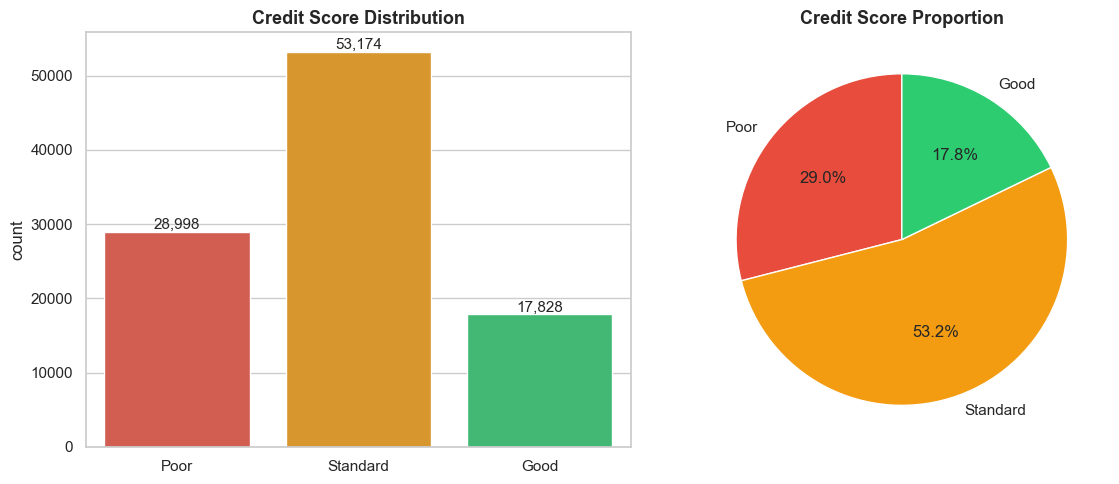

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order   = ['Poor', 'Standard', 'Good']
palette = ['#e74c3c', '#f39c12', '#2ecc71']

# Count plot
sns.countplot(data=df, x='Credit_Score', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Credit Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
counts = df['Credit_Score'].value_counts()
counts = counts.reindex(order)
axes[1].pie(counts, labels=order, autopct='%1.1f%%', colors=palette, startangle=90)
axes[1].set_title('Credit Score Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(df['Credit_Score'].value_counts())


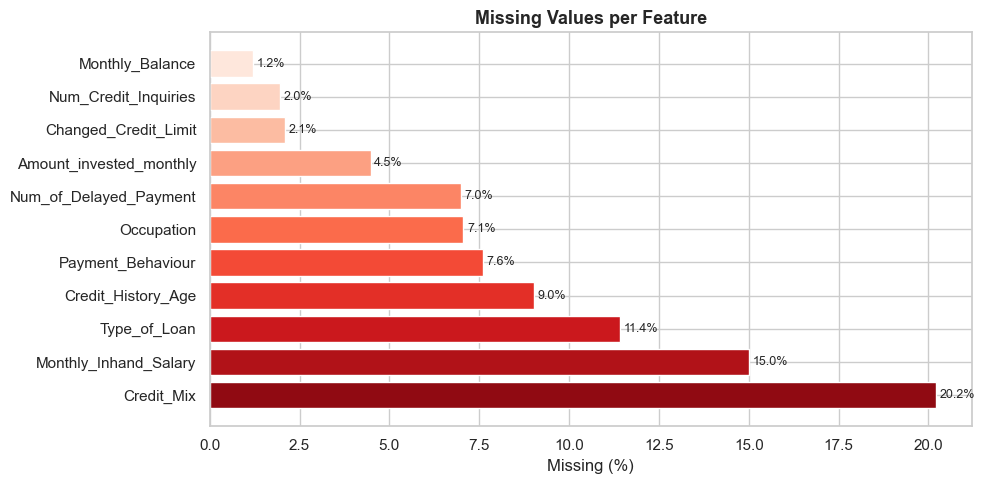

In [72]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct     = (missing / len(df) * 100).round(2)

plt.figure(figsize=(10, 5))
colors = sns.color_palette('Reds_r', len(missing))
bars   = plt.barh(missing.index, pct.values, color=colors)
plt.xlabel('Missing (%)')
plt.title('Missing Values per Feature', fontsize=13, fontweight='bold')
for bar, p in zip(bars, pct.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{p:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


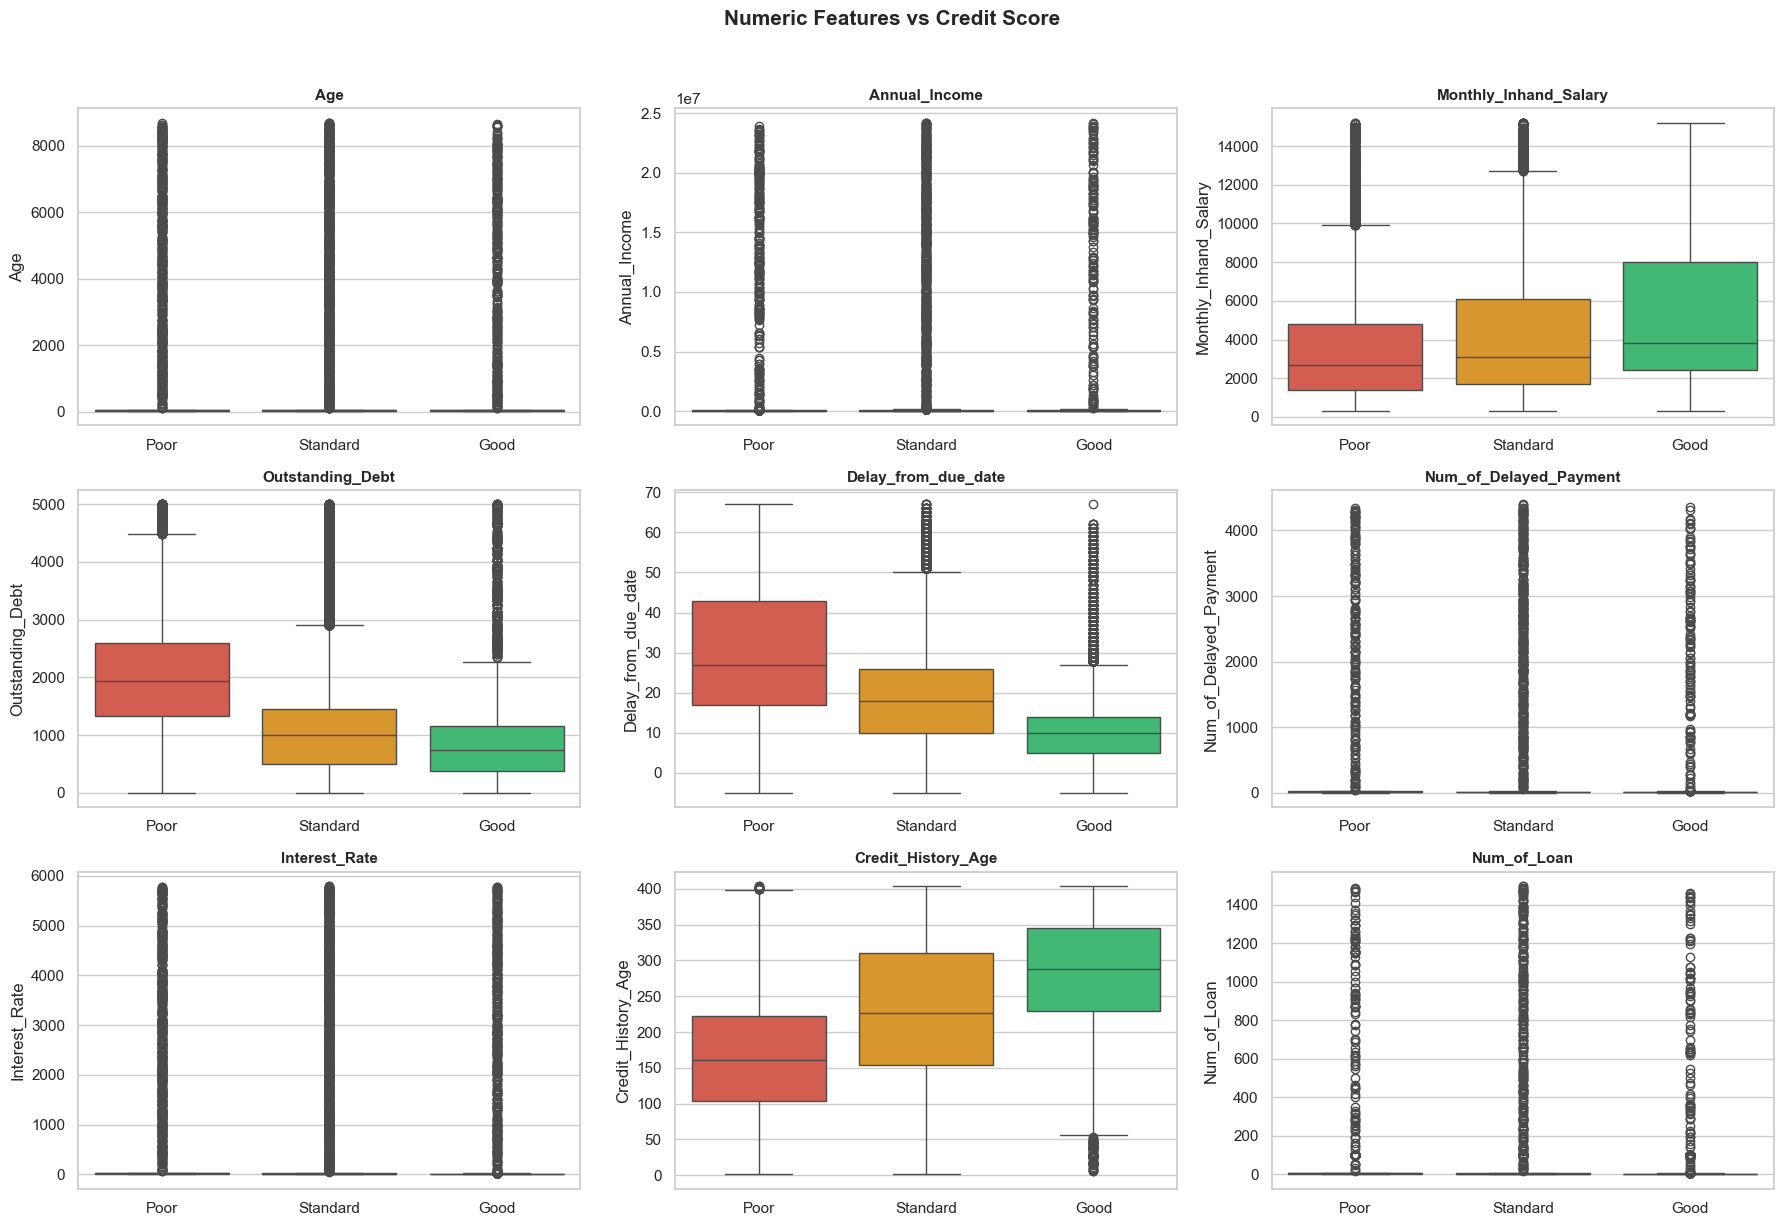

In [73]:
key_numeric = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Outstanding_Debt', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
    'Interest_Rate', 'Credit_History_Age', 'Num_of_Loan'
]
key_numeric = [c for c in key_numeric if c in df.columns]

n_cols  = 3
n_rows  = -(-len(key_numeric) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes    = axes.flatten()

order   = ['Poor', 'Standard', 'Good']
palette = {'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'}

for i, col in enumerate(key_numeric):
    sns.boxplot(data=df, x='Credit_Score', y=col, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Credit Score', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


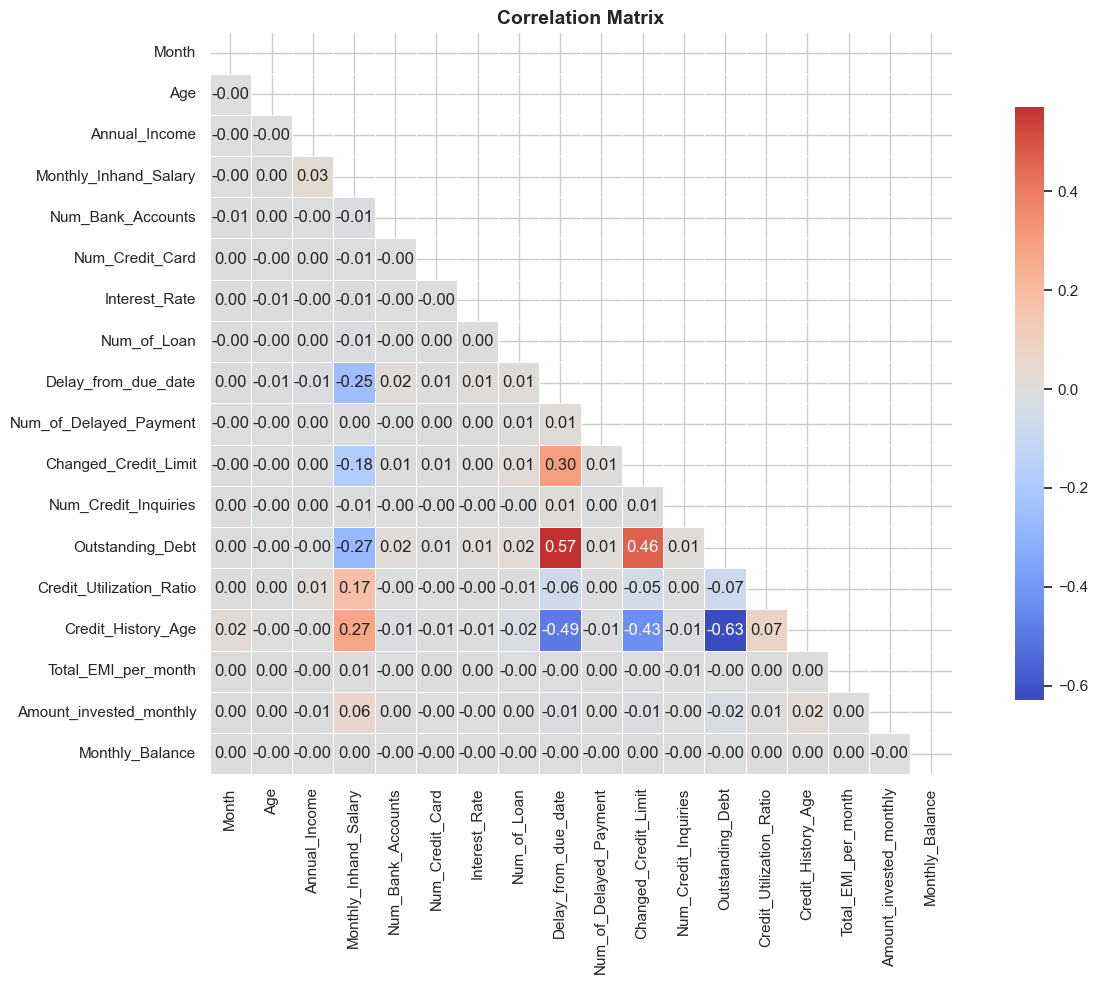

In [74]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr         = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


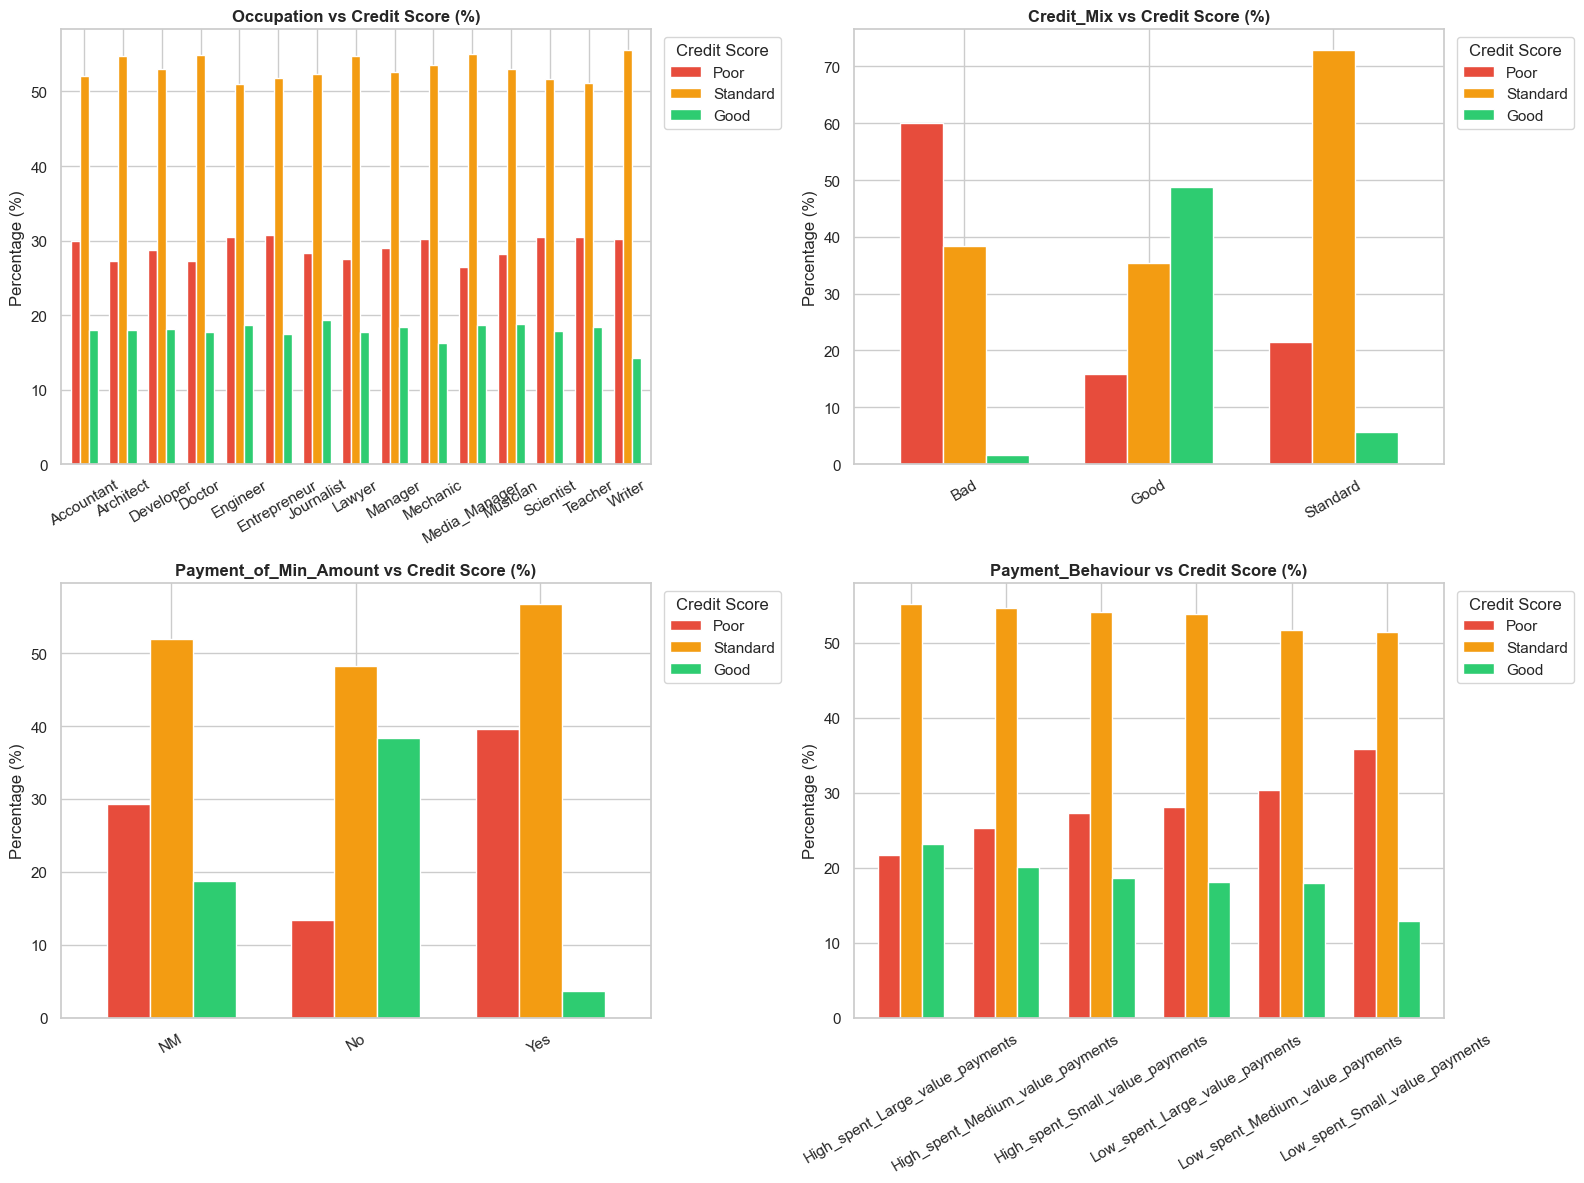

In [75]:
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
cat_cols = [c for c in cat_cols if c in df.columns]
order    = ['Poor', 'Standard', 'Good']
colors   = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Credit_Score'], normalize='index')
    for o in order:
        if o not in ct.columns:
            ct[o] = 0
    ct = ct[order] * 100
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white', width=0.7)
    axes[i].set_title(f'{col} vs Credit Score (%)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Credit Score', bbox_to_anchor=(1.01, 1))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [84]:
# Numeric → median
num_cols = [
    "Monthly_Inhand_Salary",
    "Num_Credit_Inquiries",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "Changed_Credit_Limit"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [85]:
cat_cols = [
    "Credit_History_Age",
    "Num_of_Delayed_Payment",
    "Credit_Mix"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [86]:
df.isnull().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [77]:
def clip_iqr(df, cols, factor=3.0):
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR    = Q3 - Q1
        lo, hi = Q1 - factor * IQR, Q3 + factor * IQR
        n_clip = ((df[col] < lo) | (df[col] > hi)).sum()
        df[col] = df[col].clip(lo, hi)
        print(f"  {col:35s}: {n_clip:>5,} clipped → [{lo:.2f}, {hi:.2f}]")
    return df

outlier_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Outstanding_Debt', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
    'Interest_Rate', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance', 'Credit_History_Age'
]
outlier_cols = [c for c in outlier_cols if c in df.columns]
df = clip_iqr(df, outlier_cols)
print("\nOutlier clipping done ✅")


  Age                                : 2,781 clipped → [-26.00, 93.00]
  Annual_Income                      :   999 clipped → [-140542.76, 232791.18]
  Monthly_Inhand_Salary              :     0 clipped → [-11370.07, 18953.09]
  Outstanding_Debt                   :     0 clipped → [-3573.60, 6085.63]
  Delay_from_due_date                :     0 clipped → [-44.00, 82.00]
  Num_of_Delayed_Payment             :   736 clipped → [-18.00, 45.00]
  Interest_Rate                      : 2,034 clipped → [-28.00, 56.00]
  Total_EMI_per_month                : 4,270 clipped → [-362.45, 553.98]
  Amount_invested_monthly            : 6,103 clipped → [-499.06, 839.32]
  Monthly_Balance                    : 1,562 clipped → [-330.54, 1070.99]
  Credit_History_Age                 :     0 clipped → [-330.00, 776.00]

Outlier clipping done ✅


In [78]:
# ── Target ────────────────────────────────────────────────────────────────────
credit_score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score'] = df['Credit_Score'].map(credit_score_map)
print("Target distribution after encoding:")
print(df['Credit_Score'].value_counts().sort_index())

# ── Ordinal ───────────────────────────────────────────────────────────────────
df['Credit_Mix']           = df['Credit_Mix'].map({'Bad': 0, 'Standard': 1, 'Good': 2})
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'No': 0, 'NM': 1, 'Yes': 2})

# ── Label Encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
for col in ['Occupation', 'Payment_Behaviour', 'Type_of_Loan']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"  ✓ {col}: {df[col].nunique()} unique encoded values")

print("\nEncoding done ✅")
df.dtypes


Target distribution after encoding:
Credit_Score
0    28998
1    53174
2    17828
Name: count, dtype: int64
  ✓ Occupation: 16 unique encoded values
  ✓ Payment_Behaviour: 7 unique encoded values
  ✓ Type_of_Loan: 6261 unique encoded values

Encoding done ✅


Month                         int64
Age                         float64
Occupation                    int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Type_of_Loan                  int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                  float64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount         int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour             int64
Monthly_Balance             float64
Credit_Score                  int64
dtype: object

In [79]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,12,19114.12,1824.843333,3,4,3,4.0,128,3,7.0,11.27,4.0,NaN,809.98,26.822620,265.0,0,49.574949,80.415295,2,312.494089,2
1,2,23.0,12,19114.12,NaN,3,4,3,4.0,128,-1,NaN,11.27,4.0,2.0,809.98,31.944960,NaN,0,49.574949,118.280222,3,284.629162,2
2,3,93.0,12,19114.12,NaN,3,4,3,4.0,128,3,7.0,NaN,4.0,2.0,809.98,28.609352,267.0,0,49.574949,81.699521,4,331.209863,2
3,4,23.0,12,19114.12,NaN,3,4,3,4.0,128,5,4.0,6.27,4.0,2.0,809.98,31.377862,268.0,0,49.574949,199.458074,5,223.451310,2
4,5,23.0,12,19114.12,1824.843333,3,4,3,4.0,128,6,NaN,11.27,4.0,2.0,809.98,24.797347,269.0,0,49.574949,41.420153,1,341.489231,2


In [80]:
df.isnull().sum()

Month                           0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                    0
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64